## <font color = #0288d1>图像分类</font>
### 数据准备

### MNIST数据库一共有4个文件需要下载，分别为:
### 1.  train-images-idx3-ubyte.gz：训练集
### 2.  train-labels-idx1-ubyte.gz：训练集图片对应的标签
### 3.  t10k-images-idx3-ubyte .gz：测试集
### 4.  t10k-labels-idx1-ubyte.gz：测试集标签
+ ### 下载后是4个压缩文件。将4个压缩文件解压后存放到一个文件夹中，本文是data文件夹。解压后得到的并不是一系列图片，而是.idx1-ubyte和.idx3-ubyte 格式的文件。这是一种IDX数据格式。

+ ### MNIST图像数据集使用形如<font color="purple">**28*28的数组**</font>来表示每个手写体数字，数组中的每个元素对应一个像素点，即每张图像大小固定为28\*28像素。MNIST数据集中的图像都是256阶灰度图，即灰度值0表示白色（背景），255表示黑色（前景），使用值为[0,255]的uint8数据类型表示图像。
+ ### 训练集共60000张图像而测试集有10000张图像。


>### PyTorch内建了对MNIST的支持，可以直接从pytorch得到该数据库。在下载数据库的同时，需要把数据转换为张量，然后标准化。标准化需要知道图像的均值和方差，这需要对60000张训练集中的所有图像进行处理。在此直接从网上搜索除了该数据库图片的参数，即均值为0.1307，标准差为0.3081。

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchmetrics as metrics

from torch.utils.data import DataLoader
from torchvision.transforms import Compose, ToTensor, Normalize
from torchvision import datasets

In [2]:
mean = torch.tensor(0.1307)
std = torch.tensor(0.3081)
compose = Compose([ToTensor(), Normalize(mean,std)])
train_dataset = datasets.MNIST('./data', train=True, transform=compose, download=False)
test_dataset =  datasets.MNIST('./data', train=False, transform=compose, download=False)
train_loader = DataLoader(train_dataset, batch_size=10000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2000)

In [3]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

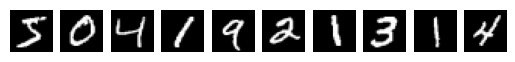

In [4]:
fig, ax = plt.subplots(1, 10)
for i in range(10):
    train = train_dataset[i][0][0].numpy()
    ax[i].imshow(train,cmap='gray')
    ax[i].axis('off')

In [5]:
class ImageShallowModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(28*28,10)
        
    def forward(self, x):
        x=self.flatten(x)
        return self.linear(x)
       

In [6]:
def mini_batch_train(data_loader,model,optimizer,loss_fn):
    mini_batch_losses = []
    for x_batch, y_batch in data_loader:
        # 置为训练状态
        model.train()
        # Step 1 - 前向计算预测值
        yhat = model(x_batch)
        # Step 2 - 计算损失
        mini_batch_loss = loss_fn(yhat, y_batch)
        # Step 3 - 计算梯度
        mini_batch_loss.backward()
        # Step 4 - 参数更新
        optimizer.step()
        optimizer.zero_grad()

        mini_batch_losses.append(mini_batch_loss.item())
                  
    loss = np.mean(mini_batch_losses)
    return loss

In [7]:
def mini_batch_val(data_loader,model,loss_fn):
    mini_batch_losses = []
    for x_batch, y_batch in data_loader:
        # 置为验证状态
        model.eval()
        # Step 1 - 前向计算预测值
        yhat = model(x_batch)
        # Step 2 - 计算损失
        mini_batch_loss = loss_fn(yhat, y_batch)
        mini_batch_losses.append(mini_batch_loss.item())
                  
    loss = np.mean(mini_batch_losses)
    return loss

In [10]:
def train(model, train_loader, test_loader, loss_fn, optimizer, epochs):
    # 指定随机数种子，可以再现数据
    np.random.seed(23)
    torch.manual_seed(23)

    # 循环轮数计数
    total_epochs = 0

    losses = []  # 每轮训练的损失
    val_losses = [] #  每轮验证数据的损失

    for _ in range(epochs):
        model.train()
        total_epochs += 1

        # 进入mini-batch的内循环
        loss = mini_batch_train(train_loader,model,optimizer,loss_fn)
        losses.append(loss)

        # 验证数据集（验证不需要计算梯度）
        with torch.inference_mode():
            # 验证集的 mini_batch
            val_loss = mini_batch_val(test_loader,model,loss_fn)
            val_losses.append(val_loss)
    
    return losses, val_losses

In [13]:
model = ImageShallowModel()
lr = 3e-3
epochs = 50
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
train_loss, val_loss = train(model, train_loader, test_loader, loss_fn, optimizer, epochs)


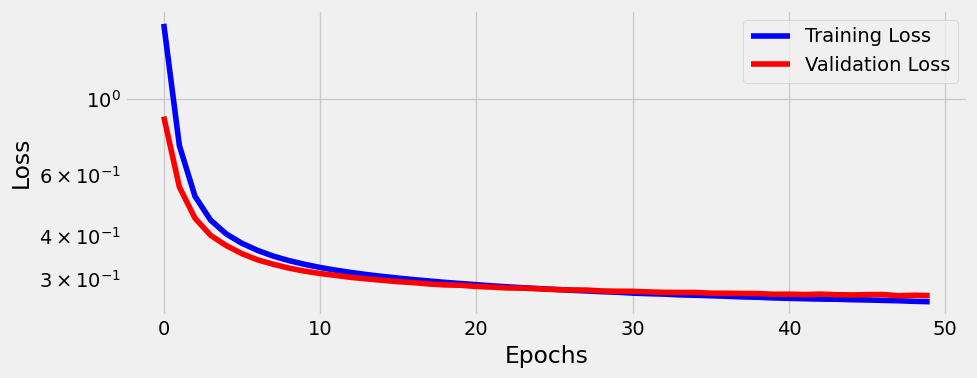

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.style.use('fivethirtyeight')
def plot_losses():
    fig = plt.figure(figsize=(10, 4))
    plt.plot(train_loss, label='Training Loss', c='b')
    plt.plot(val_loss, label='Validation Loss', c='r')
    plt.yscale('log')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    return fig

fig=plot_losses()

In [15]:
Accuracy = metrics.Accuracy(task='multiclass', num_classes=10)
for i, (x,y) in enumerate(test_loader):
    yhat = model(x)
    acc = Accuracy(yhat, y)
total_acc = Accuracy.compute()
print(f'Total accuracy: {total_acc:.4f}')

Total accuracy: 0.9236
